# Learning Urban Crimes Representation

## Exploratory Data Analysis

### Packages

In [44]:
# Packages needed
import pandas as pd # for data manipulation
import numpy as np #for numeric calculations and making simulated data.
import seaborn as sns #stylized data visualization
import matplotlib.pyplot as plt #basic data visualization

# Other packages
import warnings
warnings.filterwarnings('ignore')

# summary export packages
import json
from pathlib import Path

### Configuration

In [45]:
# pandas display options
pd.set_option("display.max_columns", 50) # to show all columns when printing a dataframe (limited to 50 cols)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}") # to show floats with 2 decimals and commas as thousand separators

### Reading data

In [46]:
# auxiliary maps

# original csv data types
dtype_map = {
    "anio_inicio": "Int64",
    "mes_inicio": "string",
    "fecha_inicio": "string",
    "hora_inicio": "string",
    "anio_hecho": "Float64",
    "mes_hecho": "string",
    "fecha_hecho": "string",
    "hora_hecho": "string",
    "delito": "string",
    "categoria_delito": "string",
    "competencia": "string",
    "fiscalia": "string",
    "agencia": "string",
    "unidad_investigacion": "string",
    "colonia_hecho": "string",
    "colonia_catalogo": "string",
    "alcaldia_hecho": "string",
    "alcaldia_catalogo": "string",
    "municipio_hecho": "string",
    "latitud": "Float64",
    "longitud": "Float64",
}

# day names from english to spanish
dias_map = {
    "Monday": "LUNES",
    "Tuesday": "MARTES",
    "Wednesday": "MIÉRCOLES",
    "Thursday": "JUEVES",
    "Friday": "VIERNES",
    "Saturday": "SÁBADO",
    "Sunday": "DOMINGO"
}


# months from english to spanish
meses_map = {
    "january": "Enero", "february": "Febrero", "march": "Marzo",
    "april": "Abril", "may": "Mayo", "june": "Junio",
    "july": "Julio", "august": "Agosto", "september": "Septiembre",
    "october": "Octubre", "november": "Noviembre", "december": "Diciembre"
}

In [47]:

# access data with proper data types
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / "data" / "raw" / "carpetasFGJ_acumulado_2025_01.csv"

data = pd.read_csv(data_path, dtype=dtype_map)


#### Initial exploration

In [48]:
# print data info and first few rows to check registers
data

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
0,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,16:30:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,DELITO DE BAJO IMPACTO,<NA>,INVESTIGACIÓN EN TLALPAN,TLP-4,UI-2CD,JARDINES EN LA MONTAÑA,Jardines En La Montaña,TLALPAN,<NA>,CDMX,19.30,-99.21
1,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,<NA>,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,<NA>,CDMX,19.29,-99.22
2,2016,Enero,2016-01-01,00:00:00,"2,016.00",Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,<NA>,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,<NA>,CDMX,19.34,-99.11
3,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:00:00,ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VI...,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,<NA>,INVESTIGACIÓN EN GUSTAVO A. MADERO,GAM-8,UI-2CD,SAN JUAN DE ARAGÓN II SECCIÓN,San Juan De Aragon Ii Seccion,GUSTAVO A. MADERO,<NA>,CDMX,19.45,-99.09
4,2016,Enero,2016-01-01,00:00:00,"2,015.00",Diciembre,2015-12-31,22:30:00,HOMICIDIOS INTENCIONALES (OTROS),HOMICIDIO DOLOSO,<NA>,INVESTIGACIÓN EN BENITO JUÁREZ,BJ-1,UI-2SD,NATIVITAS,Nativitas,BENITO JUAREZ,<NA>,CDMX,19.38,-99.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2098738,2024,Noviembre,2024-11-25 19:35:00,19:35:00,"2,024.00",Noviembre,2024-11-25 17:32:00,17:32:00,TENTATIVA DE EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,MIGUEL HIDALGO 3A SECCIÓN,Miguel Hidalgo 3a Seccion,TLALPAN,<NA>,CDMX,19.28,-99.21
2098739,2024,Noviembre,2024-11-26 19:53:00,19:53:00,"2,024.00",Noviembre,2024-11-25 11:20:00,11:20:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN IZTAP...,IZP-4,UI-3SD,SANTA BÁRBARA,Barrio Santa Barbara,IZTAPALAPA,<NA>,CDMX,19.36,-99.10
2098740,2024,Noviembre,2024-11-28 16:27:00,16:27:00,"2,024.00",Noviembre,2024-11-28 13:15:00,13:15:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,AMPLIACIÓN TORRE BLANCA,Pensil Norte,MIGUEL HIDALGO,<NA>,CDMX,19.45,-99.20
2098741,2024,Noviembre,2024-11-28 23:42:00,23:42:00,"2,024.00",Noviembre,2024-11-26 02:50:00,02:50:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,ESPERANZA,Esperanza,CUAUHTEMOC,<NA>,CDMX,19.42,-99.13


In [49]:
numeric_features = data.select_dtypes(include=['int', 'float']).columns.tolist() # get numeric feature names
print("Numeric features:", numeric_features) # print numeric feature names

text_features = data.select_dtypes(include="string").columns.tolist() # get text feature names
print("Text features:", text_features) # print text feature names

Numeric features: ['anio_inicio', 'anio_hecho', 'latitud', 'longitud']
Text features: ['mes_inicio', 'fecha_inicio', 'hora_inicio', 'mes_hecho', 'fecha_hecho', 'hora_hecho', 'delito', 'categoria_delito', 'competencia', 'fiscalia', 'agencia', 'unidad_investigacion', 'colonia_hecho', 'colonia_catalogo', 'alcaldia_hecho', 'alcaldia_catalogo', 'municipio_hecho']


In [50]:
# Describe the statistics of the data (only numeric columns)
data.describe()

,anio_inicio,anio_hecho,latitud,longitud
count,"2,098,743.00","2,098,184.00","1,997,536.00","1,997,536.00"
mean,"2,020.10","2,019.94",19.39,-99.14
std,2.58,3.07,0.07,0.06
min,"2,016.00",222.00,19.10,-100.23
25%,"2,018.00","2,018.00",19.34,-99.18
50%,"2,020.00","2,020.00",19.39,-99.14
75%,"2,022.00","2,022.00",19.44,-99.10
max,"2,025.00","2,025.00",19.58,-98.95


In [51]:
data[text_features].describe() # describe only the string columns

,mes_inicio,fecha_inicio,hora_inicio,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho
count,2098743,2098740,2098728,2098184,2098183,2097856,2098743,2098743,1034725,2098741,2098743,2097765,1996619,1974303,2073847,17586,2098743
unique,19,56540,115107,19,32513,2872,357,18,3,100,230,158,1699,1423,17,1,1
top,Octubre,2020-03-06,00:00:00,Enero,2021-01-01,12:00:00,VIOLENCIA FAMILIAR,DELITO DE BAJO IMPACTO,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-1,UI-1SD,CENTRO,Centro,CUAUHTEMOC,CDMX (indeterminada),CDMX
freq,185141,934,1484811,183889,1259,192234,261181,1711755,1000272,150858,72170,737376,65086,65266,318787,17586,2098743


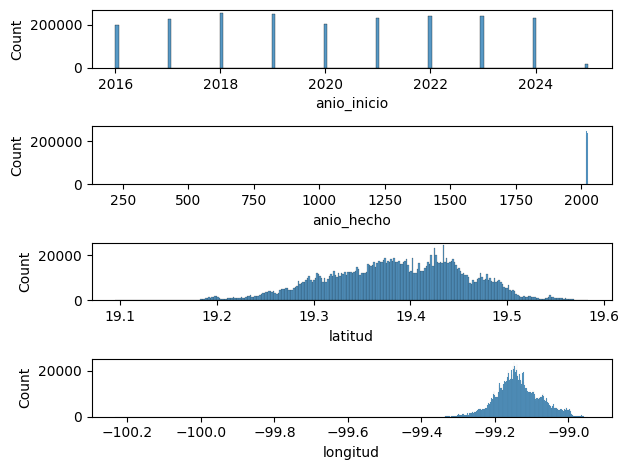

In [52]:
# plot numeric features for data quality check and exploration
num_numeric_features = len(numeric_features)

fig_raw_num_feats, axes_raw_num_feats = plt.subplots(num_numeric_features) # create subplot for numeric features (3)
for i in range(num_numeric_features):
    sns.histplot(data[numeric_features[i]], ax=axes_raw_num_feats[i]) # using for loop through numeric features list to create histogram for each feature
plt.tight_layout()

Since column "anio_hecho" exposes an atypical distribution, is interesting to explore its values. In the other hand "latitud" and "longitud" correspond to geographic positions, indicating that there should be more reports of crime in certain areas.

In [53]:
# raw unique values of anio hecho
print("raw unique values:", data["anio_hecho"].unique())

data["anio_hecho"].value_counts(dropna=False).sort_index() # counts of unique values including NaN

raw unique values: <FloatingArray>
[2015.0, 2016.0, 2014.0, 2008.0, 2012.0, 2011.0, 2013.0, 1997.0, 2009.0,
   <NA>, 2006.0, 2017.0, 2000.0, 2007.0, 2001.0, 2010.0, 2004.0, 1965.0,
 1985.0, 2003.0, 2005.0, 1987.0, 2002.0, 1998.0, 1996.0, 1986.0, 1955.0,
 1983.0, 1995.0, 1991.0, 1999.0, 1994.0, 1956.0, 1979.0, 1992.0, 1958.0,
 1966.0, 1930.0, 1915.0, 1989.0, 1984.0, 1978.0, 1975.0, 1993.0, 1976.0,
 1962.0, 1970.0, 1972.0, 1990.0, 1988.0, 1973.0, 1977.0, 1960.0, 1969.0,
 1974.0, 1980.0, 1982.0, 1981.0, 1964.0, 2018.0, 1971.0, 1957.0, 2019.0,
 1968.0, 1963.0, 2020.0, 1950.0, 1952.0, 2021.0, 1961.0, 1917.0, 2022.0,
  222.0, 1942.0, 1906.0, 1954.0, 1967.0, 2023.0, 2024.0, 2025.0]
Length: 80, dtype: Float64


anio_hecho
222.00           1
1,906.00         1
1,915.00         2
1,917.00         1
1,930.00         1
             ...  
2,022.00    237868
2,023.00    237440
2,024.00    216965
2,025.00     12516
 <NA>          559
Name: count, Length: 80, dtype: Int64

#### Column values exploration
Check unique values for all columns and null registrys to understand what does each column means

In [54]:
def extract_unique_values_summary(df):
    """
    Extracts unique values and their counts for all columns in a DataFrame.
    
    Returns a dictionary with structure:
    {
        "column_name": {
            "unique_count": int,
            "null_count": int,
            "data_type": str,
            "value_counts": {"value": count, ...}
        }
    }
    """
    summary = {}
    
    for col in df.columns:
        value_counts = data[col].value_counts(dropna=False)
        null_count = data[col].isna().sum()
        
        # Convert to serializable dict
        value_counts_dict = {}
        for key, val in value_counts.items():
            # Check if key is NaN
            if pd.isna(key):
                value_counts_dict['<NULL>'] = int(val)
            else:
                value_counts_dict[str(key)] = int(val)
        
        summary[col] = {
            "unique_count": data[col].nunique(),
            "null_count": int(null_count),
            "data_type": str(data[col].dtype),
            "value_counts": value_counts_dict
        }
    
    return summary

# Extract summary from loaded data
unique_summary = extract_unique_values_summary(data)

print(f"Extracted unique values for {len(unique_summary)} columns")

Extracted unique values for 21 columns


In [55]:
# Export to JSON for reference
output_dir = Path("../data")
output_file = output_dir / "unique_values_summary.json"

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(unique_summary, f, indent=2, ensure_ascii=False)

print(f"Exported unique values summary to: {output_file.resolve()}")# Export to JSON for reference
output_dir = Path("../data")
output_file = output_dir / "unique_values_summary.json"

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(unique_summary, f, indent=2, ensure_ascii=False)

print(f"Exported unique values summary to: {output_file.resolve()}")

Exported unique values summary to: C:\Users\adolh\Documents\8voUltimosPeriodos\notebooksReto\proy-8-grupo501-learning-latent-urban-representation\data\unique_values_summary.json
Exported unique values summary to: C:\Users\adolh\Documents\8voUltimosPeriodos\notebooksReto\proy-8-grupo501-learning-latent-urban-representation\data\unique_values_summary.json


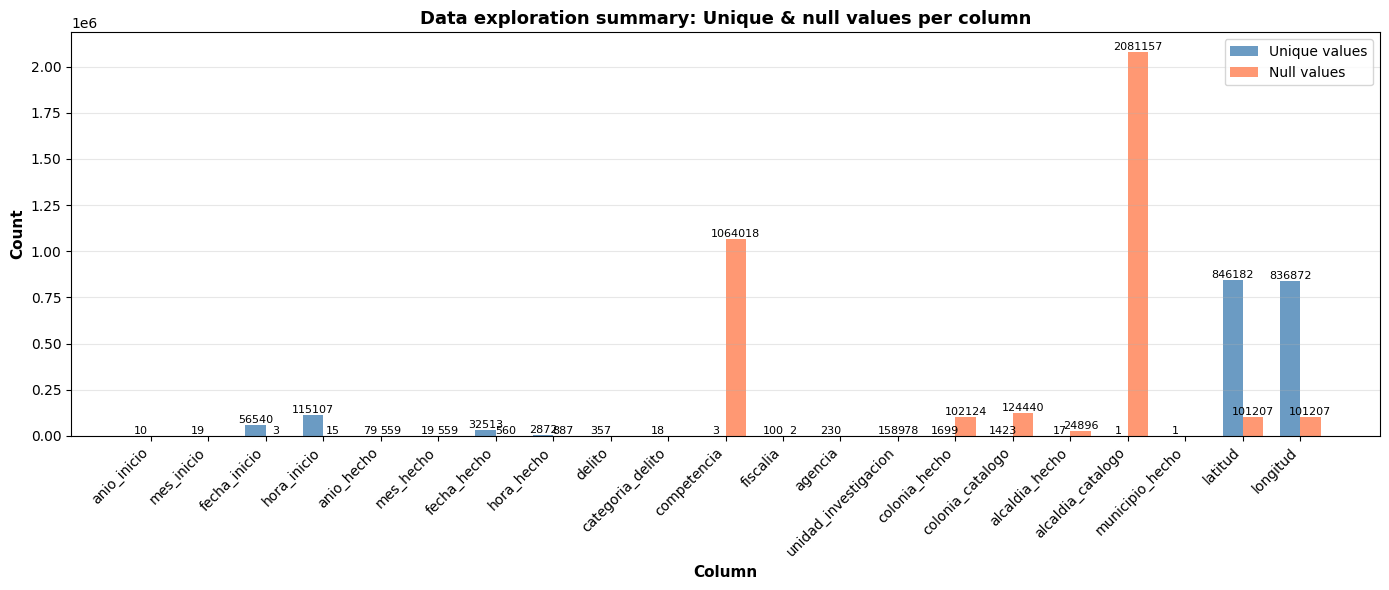

Data exploration summary

anio_inicio               | Unique:     10 | Nulls:      0

mes_inicio                | Unique:     19 | Nulls:      0

fecha_inicio              | Unique:  56540 | Nulls:      3

hora_inicio               | Unique: 115107 | Nulls:     15

anio_hecho                | Unique:     79 | Nulls:    559

mes_hecho                 | Unique:     19 | Nulls:    559

fecha_hecho               | Unique:  32513 | Nulls:    560

hora_hecho                | Unique:   2872 | Nulls:    887

delito                    | Unique:    357 | Nulls:      0

categoria_delito          | Unique:     18 | Nulls:      0

competencia               | Unique:      3 | Nulls: 1064018

fiscalia                  | Unique:    100 | Nulls:      2

agencia                   | Unique:    230 | Nulls:      0

unidad_investigacion      | Unique:    158 | Nulls:    978

colonia_hecho             | Unique:   1699 | Nulls: 102124

colonia_catalogo          | Unique:   1423 | Nulls: 124440

alcaldia_hech

In [56]:
# Visualize summary of unique values per column
fig, ax = plt.subplots(figsize=(14, 6))

columns_names = list(unique_summary.keys())
unique_counts = [unique_summary[col]['unique_count'] for col in columns_names]
null_counts = [unique_summary[col]['null_count'] for col in columns_names]

x_pos = np.arange(len(columns_names))
width = 0.35

bars1 = ax.bar(x_pos - width/2, unique_counts, width, label='Unique values', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, null_counts, width, label='Null values', color='coral', alpha=0.8)

ax.set_xlabel('Column', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Data exploration summary: Unique & null values per column', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(columns_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Data exploration summary")
for col in columns_names:
    info = unique_summary[col]
    print(f"\n{col:25} | Unique: {info['unique_count']:6} | Nulls: {info['null_count']:6}")


Reviewing the values and the json, we can consider that column alcaldia_catalogo can be discarded since the only value is CDMX and the rest is null but still corresponding to mexico city. Something similar happens to municipio_hecho which only contains the same value but since the dataset corresponds to the same state, is useless.
Columns like months require normalization and be stablished all to spanish.
unidad_investigacion will not be considered for this since corresponds to the unit in charge of processing the crime but we are not considering that as part of the data

## Data cleaning

In [57]:

print(f"Cargado: {data.shape[0]:,} registros x {data.shape[1]} columnas")
text_cols = data.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace("\r", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
print("Saltos de línea limpiados en columnas de texto")

Cargado: 2,098,743 registros x 21 columnas
Saltos de línea limpiados en columnas de texto


In [58]:
data = data.drop(columns=['hora_inicio', 'alcaldia_catalogo', 'municipio_hecho'])
print(f"Columnas eliminadas: hora_inicio, alcaldia_catalogo, municipio_hecho")
print(f"Quedan: {data.shape[1]} columnas")

Columnas eliminadas: hora_inicio, alcaldia_catalogo, municipio_hecho
Quedan: 18 columnas


In [59]:
meses_eng = {'August':'Agosto','July':'Julio','March':'Marzo',
             'April':'Abril','February':'Febrero','June':'Junio','May':'Mayo'}
data['mes_inicio'] = data['mes_inicio'].replace(meses_eng)
data['mes_hecho'] = data['mes_hecho'].replace(meses_eng)
print(f"Meses en inglés corregidos")
print(f"mes_inicio únicos: {data['mes_inicio'].nunique()}")
print(f"mes_hecho únicos: {data['mes_hecho'].nunique()}")

Meses en inglés corregidos
mes_inicio únicos: 12
mes_hecho únicos: 12


In [60]:
#Quinta celda — marcar datos no confiables:

data['fecha_sospechosa'] = (
    data['anio_hecho'].isnull() |
    (data['anio_hecho'] < 2016) |
    (data['anio_hecho'] > 2025)
)
data['hora_hecho_valida'] = (
    data['hora_hecho'].notna() &
    (data['hora_hecho'] != '00:00:00') &
    (data['hora_hecho'] != 'nan')
)
print(f"Fechas sospechosas: {data['fecha_sospechosa'].sum():,}")
print(f"Horas hecho válidas: {data['hora_hecho_valida'].sum():,}")

Fechas sospechosas: 33,158
Horas hecho válidas: 2,069,920


In [61]:
#Sexta celda — convertir 'nan' strings a nulos reales:
for col in data.columns:
    if data[col].dtype == object or str(data[col].dtype) == 'str':
        data[col] = data[col].replace('nan', np.nan)

print(f"Strings 'nan' convertidos a nulos reales")
print(f"Nulos en fiscalia: {data['fiscalia'].isnull().sum()}")
print(f"Nulos en competencia: {data['competencia'].isnull().sum():,}")

Strings 'nan' convertidos a nulos reales
Nulos en fiscalia: 2
Nulos en competencia: 1,064,018


In [62]:
#Séptima celda — verificación final y guardar:
print("Revisión final de datos de la fase 1 de limpieza")
print(f"\nRegistros: {len(data):,}")
print(f"Columnas: {data.shape[1]} → {list(data.columns)}")
print(f"\nNulos por columna:")
for col in data.columns:
    n = data[col].isnull().sum()
    if n > 0:
        print(f"  {col:25s} {n:,} ({n/len(data)*100:.1f}%)")
    else:
        print(f"  {col:25s} completa")

data.to_csv("../data/phases/carpetasFGJ_fase1.csv", index=False)
print(f"\nGuardado: carpetasFGJ_fase1.csv")

Revisión final de datos de la fase 1 de limpieza

Registros: 2,098,743
Columnas: 20 → ['anio_inicio', 'mes_inicio', 'fecha_inicio', 'anio_hecho', 'mes_hecho', 'fecha_hecho', 'hora_hecho', 'delito', 'categoria_delito', 'competencia', 'fiscalia', 'agencia', 'unidad_investigacion', 'colonia_hecho', 'colonia_catalogo', 'alcaldia_hecho', 'latitud', 'longitud', 'fecha_sospechosa', 'hora_hecho_valida']

Nulos por columna:
  anio_inicio               completa
  mes_inicio                completa
  fecha_inicio              3 (0.0%)
  anio_hecho                559 (0.0%)
  mes_hecho                 559 (0.0%)
  fecha_hecho               560 (0.0%)
  hora_hecho                887 (0.0%)
  delito                    completa
  categoria_delito          completa
  competencia               1,064,018 (50.7%)
  fiscalia                  2 (0.0%)
  agencia                   completa
  unidad_investigacion      978 (0.0%)
  colonia_hecho             102,124 (4.9%)
  colonia_catalogo          124,440 (5

In [63]:
# Cargar raw sin tocar
data_raw = pd.read_csv(data_path, dtype=dtype_map)

# Comparar valores únicos por CADA columna
print("Comparación entre el dataset original y la primera versión limpia\n")

for col in data_raw.columns:
    raw_u = data_raw[col].nunique()
    if col in data.columns:
        limpio_u = data[col].nunique()
        if raw_u == limpio_u:
            print(f"{col:25s} Raw: {raw_u:>6,}  Limpio: {limpio_u:>6,}")
        else:
            print(f"{col:25s} Raw: {raw_u:>6,}  Limpio: {limpio_u:>6,}  DIF: {raw_u - limpio_u}")
    else:
        print(f"{col:25s} Raw: {raw_u:>6,}  eliminada en fase1")

Comparación entre el dataset original y la primera versión limpia

anio_inicio               Raw:     10  Limpio:     10
mes_inicio                Raw:     19  Limpio:     12  DIF: 7
fecha_inicio              Raw: 56,540  Limpio: 56,540
hora_inicio               Raw: 115,107  eliminada en fase1
anio_hecho                Raw:     79  Limpio:     79
mes_hecho                 Raw:     19  Limpio:     12  DIF: 7
fecha_hecho               Raw: 32,513  Limpio: 32,513
hora_hecho                Raw:  2,872  Limpio:  2,872
delito                    Raw:    357  Limpio:    353  DIF: 4
categoria_delito          Raw:     18  Limpio:     18
competencia               Raw:      3  Limpio:      3
fiscalia                  Raw:    100  Limpio:     73  DIF: 27
agencia                   Raw:    230  Limpio:    230
unidad_investigacion      Raw:    158  Limpio:    155  DIF: 3
colonia_hecho             Raw:  1,699  Limpio:  1,697  DIF: 2
colonia_catalogo          Raw:  1,423  Limpio:  1,423
alcaldia_hecho 

In [64]:
# Cargar fase 1
data_phase_1 = pd.read_csv("../data/phases/carpetasFGJ_fase1.csv")

print(f"Valores únicos en 'delito': {data_phase_1['delito'].nunique()}")
print(f"Registros totales: {len(data_phase_1):,}")
print(f"Nulos en delito: {data_phase_1['delito'].isnull().sum()}")

# Todos los delitos con su frecuencia y porcentaje
print("\n")
print(f"{'DELITO':60s} {'CUENTA':>10s} {'%':>7s} {'% ACUM':>7s}")
print(f"{'='*100}")

acumulado = 0
for i, (delito, count) in enumerate(data_phase_1['delito'].value_counts().items(), 1):
    pct = count/len(data_phase_1)*100
    acumulado += pct
    print(f"{i:3d}. {delito:55s} {count:>10,} {pct:>6.1f}% {acumulado:>6.1f}%")

Valores únicos en 'delito': 353
Registros totales: 2,098,743
Nulos en delito: 0


DELITO                                                           CUENTA       %  % ACUM
  1. VIOLENCIA FAMILIAR                                         261,181   12.4%   12.4%
  2. FRAUDE                                                     156,399    7.5%   19.9%
  3. AMENAZAS                                                   135,941    6.5%   26.4%
  4. ROBO DE OBJETOS                                            112,702    5.4%   31.7%
  5. ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA              88,535    4.2%   36.0%
  6. ROBO A NEGOCIO SIN VIOLENCIA                                76,048    3.6%   39.6%
  7. ROBO DE ACCESORIOS DE AUTO                                  74,512    3.6%   43.1%
  8. ROBO DE OBJETOS DEL INTERIOR DE UN VEHICULO                 57,624    2.7%   45.9%
  9. ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VIOLENCIA       42,208    2.0%   47.9%
 10. ROBO A CASA HABITACION SIN VIOLEN

In [65]:
# ¿Cuántas categorías cubren el 80% de los registros?
acumulado = 0
for i, (delito, count) in enumerate(data_phase_1['delito'].value_counts().items(), 1):
    pct = count/len(data_phase_1)*100
    acumulado += pct
    if acumulado >= 80:
        print(f"Las primeras {i} categorías cubren el 80% del dataset")
        break

# ¿Cuántas tienen menos de 100 registros?
pocos = (data_phase_1['delito'].value_counts() < 100).sum()
print(f"Categorías con menos de 100 registros: {pocos} de 353")

# ¿Cuántas tienen menos de 10?
muy_pocos = (data_phase_1['delito'].value_counts() < 10).sum()
print(f"Categorías con menos de 10 registros: {muy_pocos} de 353")

# Ver las categorías raras (menos de 10 registros)
print(f"\nCategorías con menos de 10 registros:")
for d, c in data_phase_1['delito'].value_counts().tail(50).items():
    if c < 10:
        print(f"  {c:>5,}  {d}")

Las primeras 42 categorías cubren el 80% del dataset
Categorías con menos de 100 registros: 110 de 353
Categorías con menos de 10 registros: 37 de 353

Categorías con menos de 10 registros:
      9  INTIMIDACION (EVITAR DENUNCIA, APORTE INFORMACIÓN O PRUEBAS)
      9  ROBO A SUCURSAL BANCARIA (SUPERMERCADO) CON VIOLENCIA
      9  OPERACIONES CON RECURSOS DE PROCEDENCIA ILEGAL
      9  ROBO A PASAJERO A BORDO DE CABLEBUS SIN VIOLENCIA
      9  VIOLACION TUMULTUARIA EQUIPARADA POR CONOCIDO
      8  ROBO A SUCURSAL BANCARIA DENTRO DE TIENDAS DE AUTOSERVICIO S/V
      6  COACCION DE SERVIDORES PUBLICOS
      6  ULTRAJES
      5  MOTIN
      5  PERDIDA DE LA VIDA POR ENVENENAMIENTO
      5  ROBO A PASAJERO A BORDO DE CABLEBUS CON VIOLENCIA
      5  LEY FEDERAL DE ARMAS DE FUEGO Y EXPLOSIVOS
      4  DESACATO
      4  DENUNCIA DE HECHOS POR ROBO DE CELULAR
      3  PERSONAS EXTRAVIADAS
      3  CONTAGIO VENERERO
      3  PROCREACION ASISTIDA, INSEMINACION ARTIFICIAL Y ESTERILIZACION FORZADA
